---
title: "SafeYield: Wildfire Risk and Real Estate Valuation"
subtitle: "Team Z, Big Data Technology"
author: "Giovanni Cantù, Lorenzo Dufour, Louise Hinard"
date: 2026-05-14
---

In [1]:
# ──────────────────────────────────────────────────────────────────────────────
# SafeYield report ── data pipeline
# Loads four open datasets, builds a 200-zone spatial model of mainland
# Portugal, scores each zone for wildfire risk, and applies the resulting
# index as a discount to median property prices.
# ──────────────────────────────────────────────────────────────────────────────

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Configuration ───────────────────────────────────────────────────────────
DATA_DIR        = Path('Data')
FIRE_PATH       = DATA_DIR / 'all_data_ptcontinental_1980_2021.csv'
GEO_PATH        = DATA_DIR / 'concelhos_centroids_mainland_table.csv'
HOUSES_PATH     = DATA_DIR / 'portugal_houses.csv'
LISTINGS_PATH   = DATA_DIR / 'portugal_listinigs.csv'

N_ZONES         = 200      # K-Means partitions over mainland Portugal
MAX_DISCOUNT    = 0.20     # Max price impact applied in the highest-risk zone
RISK_WEIGHTS    = {        # Composite weights for the Risk Index
    'fire_count':   0.4,   # how often fires occur
    'total_burned': 0.4,   # cumulative damage footprint
    'avg_burned':   0.2,   # typical event severity
}

# ── 1. Wildfire data ────────────────────────────────────────────────────────
# Join the raw fire log with the administrative geography table so that every
# fire event carries its district and municipality identifiers.
fires_raw = pd.read_csv(FIRE_PATH)
geo_admin = pd.read_csv(GEO_PATH, usecols=['NAME_1', 'NAME_2', 'ID_1', 'ID_2'])

df_fires = (
    fires_raw
    .merge(geo_admin, left_on='Concelho', right_on='NAME_2', how='left')
    .drop(columns=['NAME_2'])
    .rename(columns={
        'Concelho': 'Municipality',
        'Mês':      'Month',
        'Ano':      'Year',
        'Área':     'Burned_Area',
        'lon':      'Longitude',
        'lat':      'Latitude',
        'datetime': 'Timestamp',
        'NAME_1':   'District',
        'ID_1':     'District_ID',
        'ID_2':     'Municipality_ID',
    })
)
df_fires['Timestamp'] = pd.to_datetime(df_fires['Timestamp'])

# ── 2. Real estate data ─────────────────────────────────────────────────────
# Two sources: a structured houses file (transactions) and a listings file
# (live market). Drop columns with more than 25% missingness, then bring
# city-level median listing prices into the houses table as a market anchor.
houses   = pd.read_csv(HOUSES_PATH)
listings = pd.read_csv(LISTINGS_PATH)

houses   = houses.loc[:,   houses.isnull().mean()   < 0.25]
listings = listings.loc[:, listings.isnull().mean() < 0.25]

listings_city = (
    listings
    .groupby('City', as_index=False)['Price']
    .median()
)

# Normalize join keys so that "Lisboa", "lisboa " and "LISBOA" all match.
houses['location']    = houses['location'].astype(str).str.lower().str.strip()
listings_city['City'] = listings_city['City'].astype(str).str.lower().str.strip()

df_housing = (
    houses
    .merge(listings_city, left_on='location', right_on='City', how='left')
    .dropna(subset=['price_int'])
)

# Median-impute numeric nulls so the spatial model has no missing inputs.
num_cols = df_housing.select_dtypes(include=np.number).columns
df_housing[num_cols] = df_housing[num_cols].fillna(df_housing[num_cols].median())

# ── 3. Spatial zoning (K-Means, k = 200) ────────────────────────────────────
# Fit the scaler on raw numpy arrays so that the fire-side transform is not
# tied to the housing-side column names.
geo_scaler   = StandardScaler()
house_coords = geo_scaler.fit_transform(df_housing[['latitude', 'longitude']].to_numpy())

kmeans = KMeans(n_clusters=N_ZONES, random_state=42, n_init=10)
df_housing['zone'] = kmeans.fit_predict(house_coords)

fire_coords      = geo_scaler.transform(df_fires[['Latitude', 'Longitude']].to_numpy())
df_fires['zone'] = kmeans.predict(fire_coords)

# ── 4. Risk Index per zone ──────────────────────────────────────────────────
zone_stats = (
    df_fires
    .groupby('zone')
    .agg(
        fire_count   = ('Burned_Area', 'count'),
        total_burned = ('Burned_Area', 'sum'),
        avg_burned   = ('Burned_Area', 'mean'),
    )
    .reset_index()
    .fillna(0)
)

# Min-max scale each driver before blending so no single metric dominates.
scaler_metrics = MinMaxScaler()
metric_cols    = list(RISK_WEIGHTS.keys())
zone_stats[metric_cols] = scaler_metrics.fit_transform(zone_stats[metric_cols])

zone_stats['risk_index'] = sum(
    w * zone_stats[m] for m, w in RISK_WEIGHTS.items()
)

# ── 5. Risk-adjusted valuation ──────────────────────────────────────────────
zone_prices = df_housing.groupby('zone', as_index=False)['price_int'].mean()

impact_df = (
    zone_prices
    .merge(zone_stats[['zone', 'risk_index']], on='zone', how='left')
    .fillna(0)
)
impact_df['risk_scaled']    = impact_df['risk_index'] / impact_df['risk_index'].max()
impact_df['price_adjusted'] = impact_df['price_int'] * (1 - MAX_DISCOUNT * impact_df['risk_scaled'])
impact_df['gap_eur']        = impact_df['price_int'] - impact_df['price_adjusted']

# ── 6. Summary values used in the prose ─────────────────────────────────────
n_fires      = len(df_fires)
n_houses     = len(df_housing)
year_min     = int(df_fires['Year'].min())
year_max     = int(df_fires['Year'].max())
n_years      = year_max - year_min + 1
total_ha     = float(df_fires['Burned_Area'].sum())

avg_gap_eur  = float(impact_df['gap_eur'].mean())
top_gap_eur  = float(impact_df['gap_eur'].max())
max_pct      = int(MAX_DISCOUNT * 100)

# Ranked districts by total burned area (used in the results table).
top_districts = (
    df_fires
    .dropna(subset=['District'])
    .groupby('District')
    .agg(
        events        = ('Burned_Area', 'count'),
        total_burned  = ('Burned_Area', 'sum'),
    )
    .sort_values('total_burned', ascending=False)
    .head(5)
    .reset_index()
)
top_districts['events']       = top_districts['events'].map(lambda x: f"{x:,}")
top_districts['total_burned'] = top_districts['total_burned'].map(lambda x: f"{x:,.0f}")
top_districts.columns         = ['District', 'Fire events', 'Total burned (ha)']

# Render the small ranking as a Markdown pipe table without any extra
# dependencies (avoids requiring the `tabulate` package).
def _df_to_markdown(df: pd.DataFrame) -> str:
    header    = '| ' + ' | '.join(df.columns) + ' |'
    separator = '|' + '|'.join(['---'] * len(df.columns)) + '|'
    body      = '\n'.join('| ' + ' | '.join(map(str, row)) + ' |' for row in df.values)
    return '\n'.join([header, separator, body])

top_districts_md = _df_to_markdown(top_districts)

## Summary

SafeYield is a B2B data platform that prices wildfire exposure into Portuguese real estate, producing a zone-level Risk Index and a risk-adjusted valuation for any property location.

## Big Data Justification

The pipeline joins `{python} f"{n_fires:,}"` fire events covering `{python} n_years` years (`{python} year_min` to `{python} year_max`) with `{python} f"{n_houses:,}"` real estate records from two independent sources. Together the inputs cross the five-Vs threshold:

| Dimension | How SafeYield qualifies |
|-----------|------------------------|
| **Volume** | `{python} f"{n_fires:,}"` fire events and `{python} f"{n_houses:,}"` property records across four decades, totalling roughly `{python} f"{total_ha/1e6:.1f}"` million hectares cumulative burned area across all recorded events. |
| **Variety** | Time-series CSVs, spatial coordinates, administrative geography, and live market listing metadata combined in a single feature surface. |
| **Veracity** | Automated joins resolve naming mismatches between government and commercial sources; columns above 25% missingness are dropped, the rest median-imputed. |
| **Velocity** | The trained spatial model assigns any new fire event to its zone and updates the index in seconds. |
| **Value** | Open environmental data is converted into a proprietary financial signal that drives pricing and capital allocation. |

## Business Case

**Beneficiaries.** Insurance underwriters use the Risk Index to replace district-level rate tables with zone-level pricing, reducing mispricing on both sides of the tail. Real estate investors and REITs screen for low-risk zones where prices have not yet absorbed the environmental discount, and avoid high-risk zones where downside is structural. Public agencies route forest management spend toward areas where financial vulnerability, not just physical fire history, is highest.

**Monetization.** Two streams: tiered API access embedded in property portal listings, priced per call, and one-shot risk audits sold to insurers and lenders. Source data is open, so the marginal cost of an extra API call is essentially compute. Margin scales with contract count rather than data licensing, which keeps the model sustainable as volume grows.

## Innovation

**Differentiation.** Most Portuguese portals show environmental risk as a binary flag or a district label. SafeYield replaces that with a continuous index calibrated at the zone level, and translates the index into an explicit euro impact that an underwriter or buyer can act on.

**Technology.** Property coordinates are standardized and clustered with K-Means into `{python} N_ZONES` zones. Every historical fire event is projected into its nearest zone using the same scaler. A composite Risk Index combines three normalized drivers: fire frequency, cumulative burned area, and average event severity, weighted 40 / 40 / 20. The index then sets a discount of up to `{python} max_pct`% on the zone median price, producing the risk-adjusted valuation displayed below.

**Growth.** Three steps move the prototype to commercial product: integrating live weather and fuel-load feeds so the index responds within a fire season, signing API partnerships with the top Portuguese property portals, and extending the same pipeline to Spain and Greece, which share the Mediterranean fire profile.

## Results

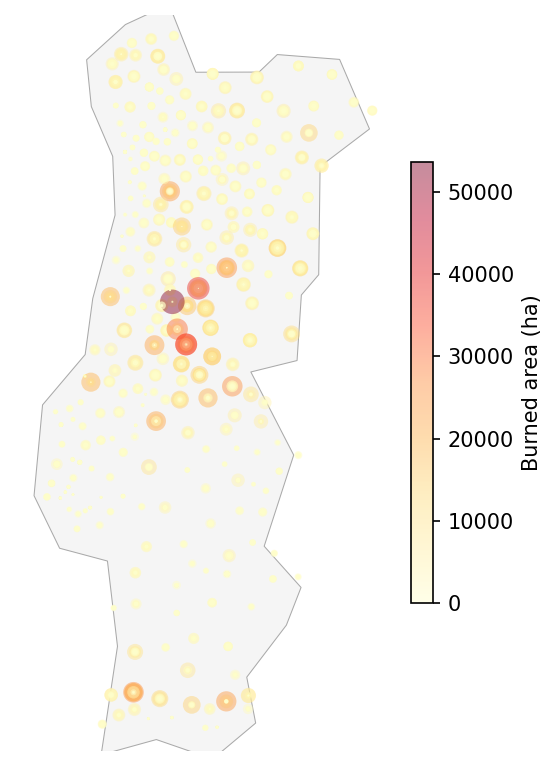

In [2]:
PORTUGAL_GEOJSON = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries/PRT.geo.json"

fig, ax = plt.subplots(figsize=(4.4, 5.2))
try:
    portugal = gpd.read_file(PORTUGAL_GEOJSON)
    portugal.plot(ax=ax, color='#f5f5f5', edgecolor='#aaaaaa', linewidth=0.5)
except Exception:
    pass

# Use sqrt of area for marker size so a few huge events do not swamp the map.
sizes = np.sqrt(df_fires['Burned_Area'].clip(lower=0)) * 0.6

sc = ax.scatter(
    df_fires['Longitude'], df_fires['Latitude'],
    s=sizes,
    c=df_fires['Burned_Area'],
    cmap='YlOrRd', alpha=0.45, linewidths=0,
)
ax.set_xlim([-9.7, -6.1])
ax.set_ylim([36.9, 42.2])
ax.set_axis_off()
plt.colorbar(sc, ax=ax, label='Burned area (ha)', shrink=0.6, pad=0.02)
plt.tight_layout()
plt.show()

Fire activity concentrates in the central and northern interior. The five districts that account for the largest cumulative burn footprint are listed below.

In [3]:
from IPython.display import Markdown
Markdown(top_districts_md)

| District | Fire events | Total burned (ha) |
|---|---|---|
| Guarda | 3,938 | 741,230 |
| Castelo Branco | 2,826 | 499,443 |
| Viseu | 6,803 | 480,792 |
| Coimbra | 4,511 | 435,462 |
| Vila Real | 4,097 | 389,425 |

Top five districts by cumulative burned area, 1980 to 2021.

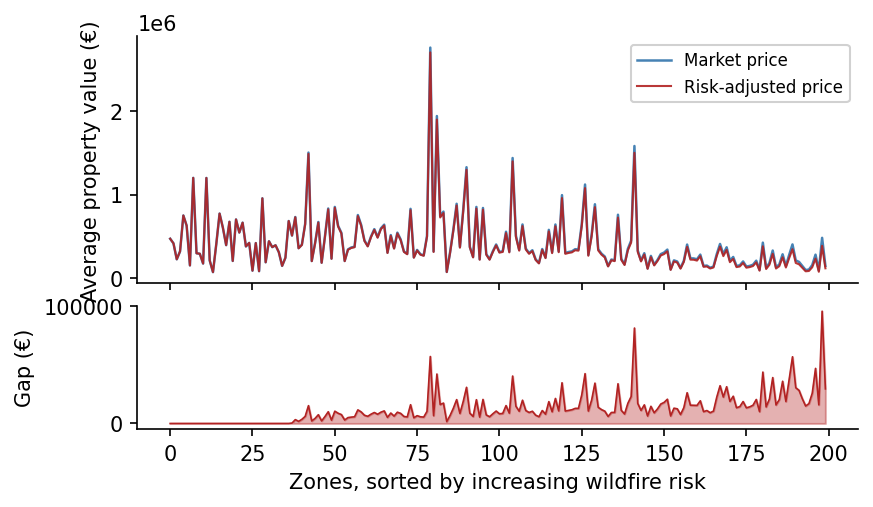

In [4]:
impact_sorted = impact_df.sort_values('risk_scaled').reset_index(drop=True)
x = impact_sorted.index

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(6.2, 3.4), sharex=True,
    gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.12},
)

# Top panel: market vs. adjusted price.
ax_top.plot(x, impact_sorted['price_int'],      label='Market price',        color='steelblue', linewidth=1.2)
ax_top.plot(x, impact_sorted['price_adjusted'], label='Risk-adjusted price', color='firebrick', linewidth=1.0, alpha=0.9)
ax_top.set_ylabel('Average property value (€)')
ax_top.legend(framealpha=0.9, loc='upper right', fontsize=8)

# Bottom panel: valuation gap in absolute euros, so the spread is legible.
ax_bot.fill_between(x, 0, impact_sorted['gap_eur'], color='firebrick', alpha=0.35)
ax_bot.plot(x, impact_sorted['gap_eur'], color='firebrick', linewidth=0.8)
ax_bot.set_ylabel('Gap (€)')
ax_bot.set_xlabel('Zones, sorted by increasing wildfire risk')

plt.tight_layout()
plt.show()

The gap widens with risk. The average gap across the 200 zones is roughly `{python} f"€{avg_gap_eur:,.0f}"`, and the worst-affected zone carries a projected discount of `{python} f"€{top_gap_eur:,.0f}"`, equal to the `{python} max_pct`% ceiling. Low-risk zones show no adjustment, which confirms the index applies pressure selectively rather than uniformly across the territory.

## Prototype Maturity

**Functionality.** The pipeline runs end-to-end: it ingests the four CSV sources, builds the spatial model, scores every zone, and writes out adjusted valuations and the figures shown above. Render time on a laptop is under one minute.

**Accessibility.** Source code, raw data, and the rendered report are in the public [Google Drive folder](https://drive.google.com/drive/folders/1-P3whso2JyT89ydIl285xuN8srP4Y7lJ). The `wildfire.ipynb` notebook in that folder can be opened directly in Google Colab for interactive execution. No login is required.

**Limitations.** The model is calibrated on historical frequency only; it does not yet absorb climate projections or fuel-load forecasts. The `{python} N_ZONES`-zone grid is roughly municipal in resolution, so neighbourhood-level scoring would need denser housing data and more clusters. The discount curve is set for residential property and would need recalibration for industrial and agricultural assets.

## User Stories

- *As an insurance underwriter*, I want a zone-level wildfire risk score so that I can price policies on verified local exposure rather than district averages.
- *As a real estate investor*, I want to filter zones by environmental risk so that I can deploy capital where downside is structurally limited.
- *As a homebuyer*, I want to see the wildfire risk on a property listing so that I can factor it into my offer before signing.

## References

**Wildfire dataset:** Instituto da Conservação da Natureza e das Florestas (ICNF), Portugal open data portal. **Real estate datasets:** Idealista Portugal public listings and the aggregated houses transaction file. **Administrative geography:** GADM, mainland Portugal concelho boundaries. **Basemap:** `world.geo.json` (johan/world.geo.json, public domain).